In [13]:
import gdsfactory as gf
from ihp import PDK
from ihp.cells.capacitors import cmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

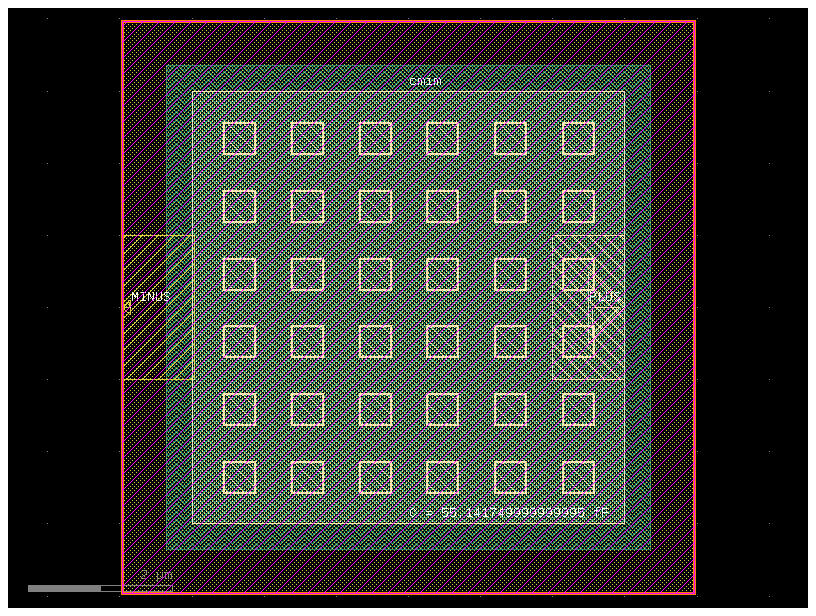

In [14]:
c = cmim(width=6.0, length=6.0)

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [ ]:
# Checking the port layers.
cc.ports

["Port(self.name='MINUS', self.width=200, trans=r180 *1 -3.86,0, layer=Metal5pin (67/2), port_type=electrical)", "Port(self.name='PLUS', self.width=1000, trans=r0 *1 2.5,0, layer=TopMetal1pin (126/2), port_type=electrical)"]

In [ ]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-cmim")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=5.0)

# MINUS is assigned as P1 by gdsfactory (component port order), so it must be
# excited=True to ensure Palace excites P1 and generates S[1][1] and S[2][1].
sim.add_port("PLUS",from_layer="metal5",to_layer="topmetal1",geometry="via",excited=False)
sim.add_port("MINUS",from_layer="metal5",to_layer="topmetal1",geometry="via",excited=True)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
# If we try to mesh the geometry with planar_conductors=False, we get the following error:
# Error   : Unknown model face with tag 7

# TODO: investigate why Z dimension is much larger than expected
sim.mesh(preset="graded",margin=1.0, refined_mesh_size=0.2,planar_conductors=True)

Mesh Summary
Dimensions: 9.9 x 9.9 x 23.3 µm
Nodes:      2,672
Elements:   18,025
Tetrahedra: 14,685
Edge length: 0.06 - 9.93 µm
Quality:    0.620 (min: 0.113)
SICN:       0.658 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (10):
  - metal5_pec [4]
  - topmetal1_pec [5]
  - vmim_pec [6]
  - P1 [7]
  - P2 [8]
  - SiO2__None [9]
  - SiO2__passive [10]
  - passive__None [11]
  - air__passive [12]
  - air__None [13]
----------------------------------------
Mesh:   runs/palace-sim-cmim/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:50:08.101 (2115.987s) [    7547D4A78080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:50:08.110 (2115.997s) [    7547D4A78080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:50:08.141 (2116.027s) [    7547D4A78080]vt

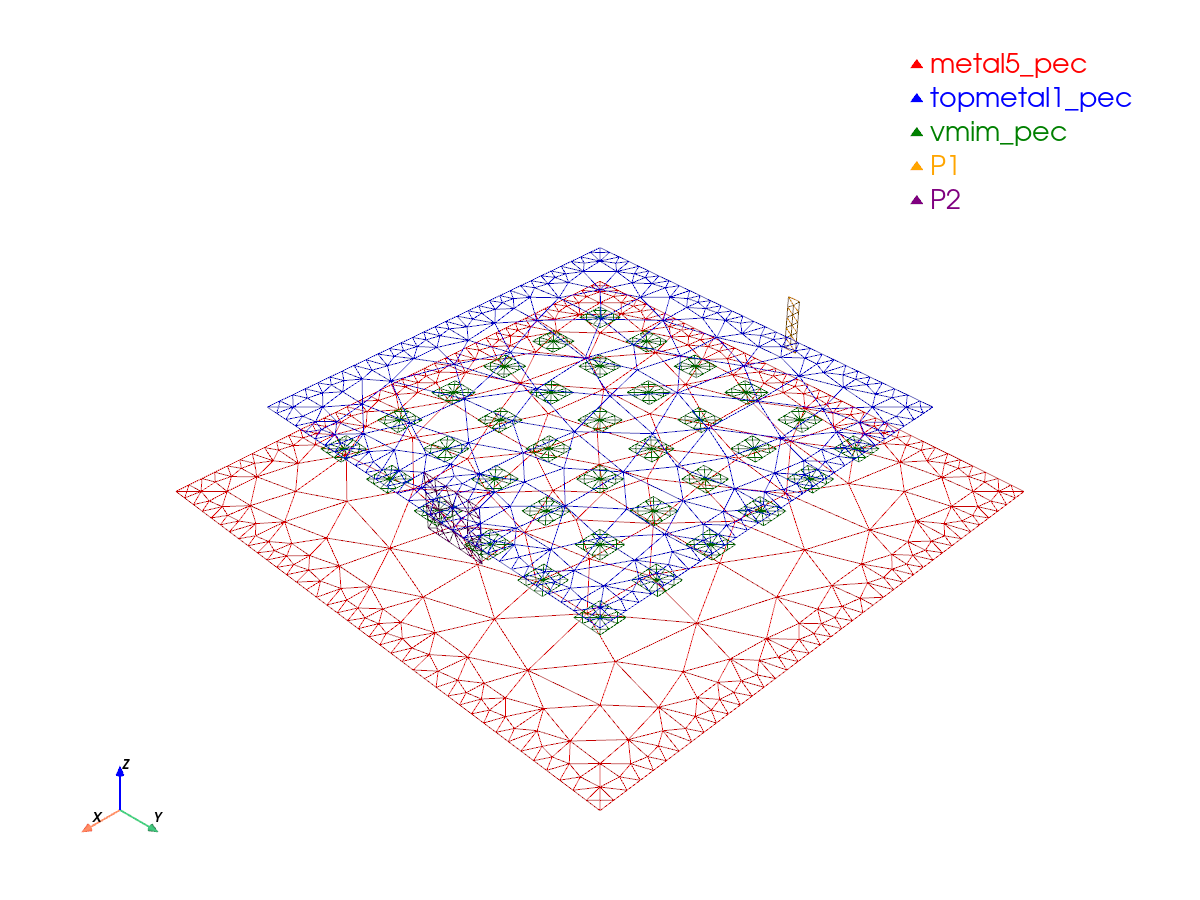

In [18]:
sim.plot_mesh(show_groups=["metal","vmim","P"], interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:50:08.365 (2116.251s) [    7547D4A78080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:50:08.374 (2116.261s) [    7547D4A78080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:50:08.399 (2116.285s) [    7547D4A78080]vt

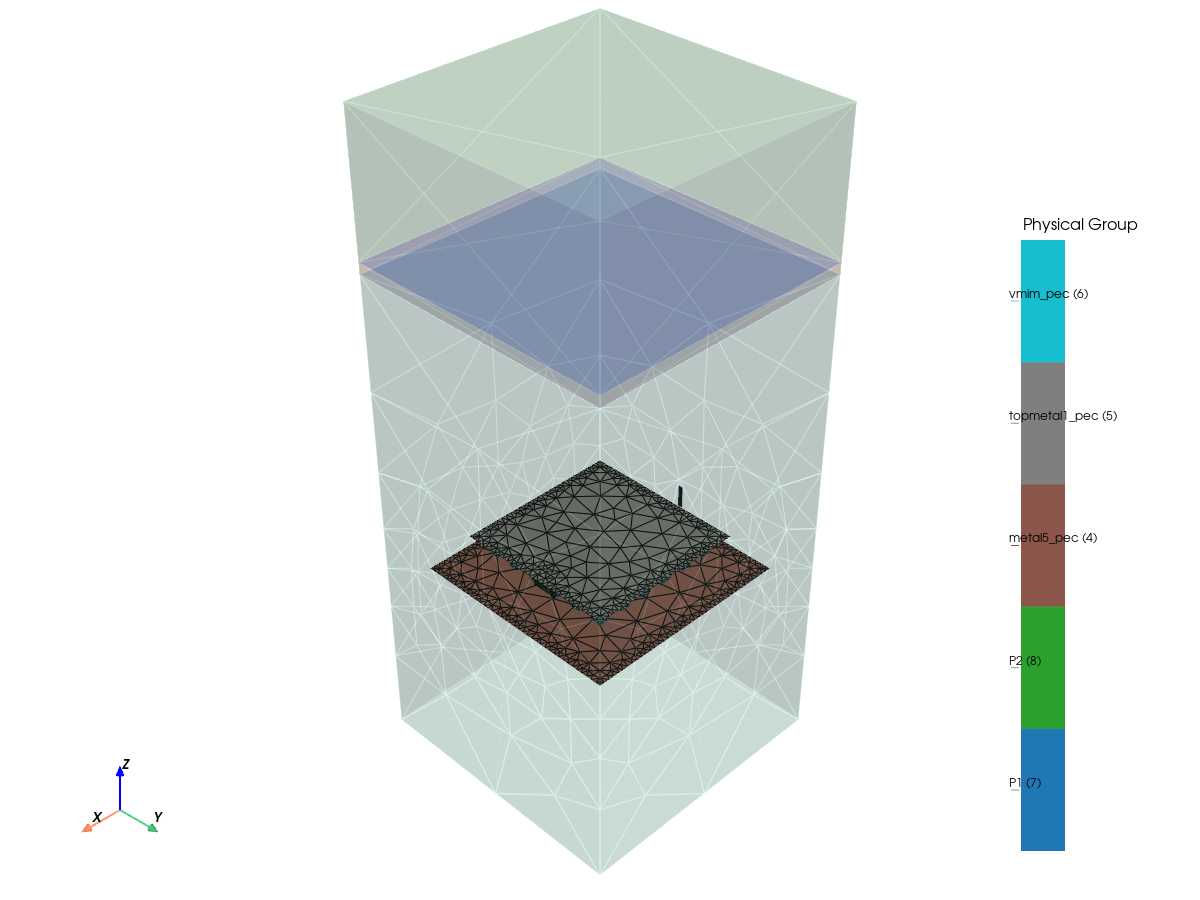

In [19]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [20]:
results = sim.run(parent_dir="runs")

  palace-7f1f99bc  completed  0m 23s
Extracting results.tar.gz...
Downloaded 6 files to runs/sim-data-palace-7f1f99bc


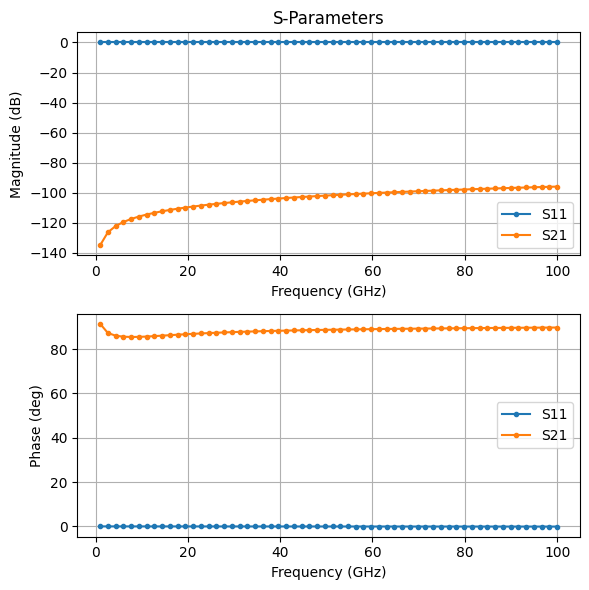

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()